# 05: War Dependency

Data: carnegie_dualuse_monthly, mdi_monthly_2022_2024, panel_monthly_var
Period: 2022-03–2024-10
N: 32 months
Result: MDI 2.67–7.98% (mean 3.89%). Carnegie ~300 M$/mo dual-use.

In [1]:
# ============================================================
# Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})

_candidates = [Path.cwd(), Path.cwd().parent]
for c in _candidates:
    _proj = c / "russia_china_dependency"
    if _proj.exists() and (_proj / "02_processed_data").exists():
        PROJECT_ROOT = c
        break
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED = PROJECT_ROOT / "russia_china_dependency" / "02_processed_data"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup OK |", FIGURES)

Setup OK | d:\Users\Proprietaire\Desktop\Projet_perso\Chine-russie\reports\figures


In [2]:
# ============================================================
# Load data
# ============================================================

mdi = pd.read_csv(PROCESSED / "mdi_monthly_2022_2024.csv", parse_dates=["date"])
carnegie = pd.read_csv(PROCESSED / "carnegie_dualuse_monthly.csv")
panel = pd.read_csv(PROCESSED / "panel_monthly_var.csv", parse_dates=["date"], index_col="date")

print("MDI:", mdi["date"].min(), "to", mdi["date"].max(), "| N =", len(mdi))
print("Carnegie categories:", carnegie["category"].unique().tolist())
print("Panel:", panel.index.min(), "to", panel.index.max())

MDI: 2022-03-01 00:00:00 to 2024-10-01 00:00:00 | N = 32
Carnegie categories: ['semiconductors', 'machine_tools', 'telecom']
Panel: 2017-01-01 00:00:00 to 2024-12-01 00:00:00


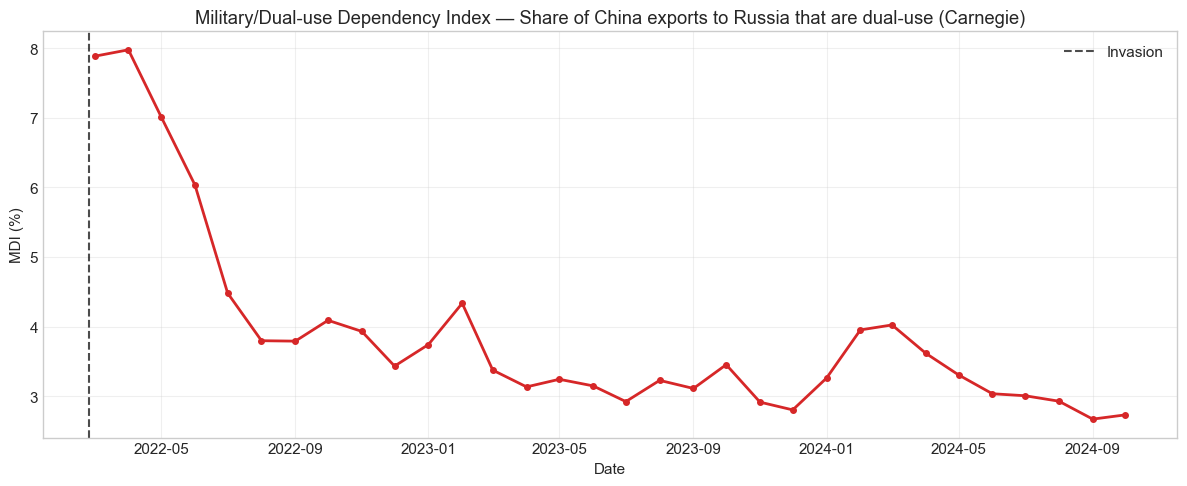

MDI: min=2.67%, max=7.98%, mean=3.89%


In [3]:
# ============================================================
# MDI Timeline (share of dual-use in China exports to Russia)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mdi["date"], mdi["mdi_pct"], color="#d62728", linewidth=2, marker="o", markersize=4)
ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", alpha=0.7, label="Invasion")
ax.set_xlabel("Date")
ax.set_ylabel("MDI (%)")
ax.set_title("Military/Dual-use Dependency Index — Share of China exports to Russia that are dual-use (Carnegie)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "mdi_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"MDI: min={mdi['mdi_pct'].min():.2f}%, max={mdi['mdi_pct'].max():.2f}%, mean={mdi['mdi_pct'].mean():.2f}%")

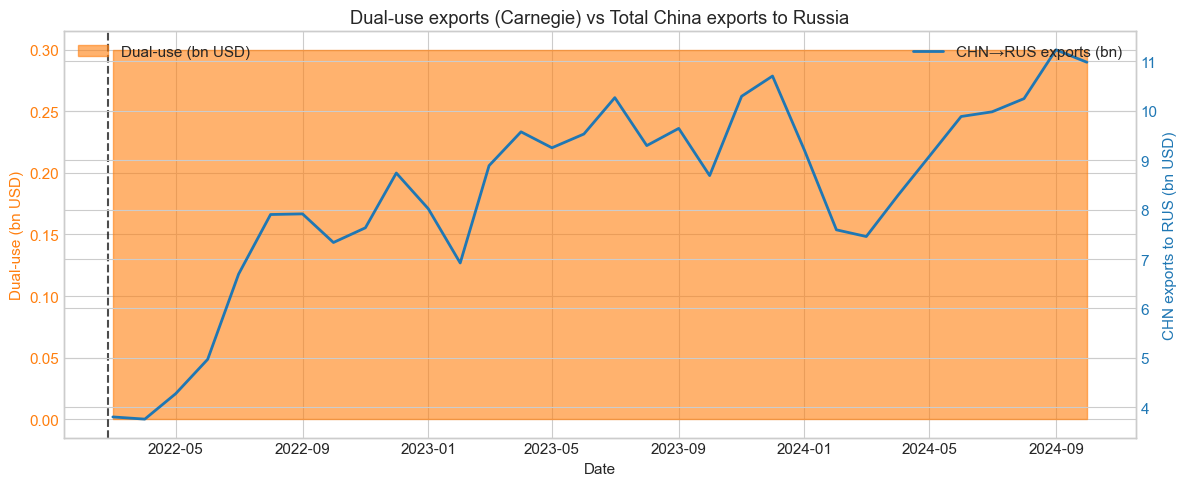

In [4]:
# ============================================================
# Dual-use (bn) vs China exports (bn) — Twin axis
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.fill_between(mdi["date"], 0, mdi["dual_use_bn"], color="#ff7f0e", alpha=0.6, label="Dual-use (bn USD)")
ax1.set_ylabel("Dual-use (bn USD)", color="#ff7f0e")
ax1.tick_params(axis="y", labelcolor="#ff7f0e")

ax2 = ax1.twinx()
ax2.plot(mdi["date"], mdi["CHN_exp_to_RUS_bn"], color="#1f77b4", linewidth=2, label="CHN→RUS exports (bn)")
ax2.set_ylabel("CHN exports to RUS (bn USD)", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

ax1.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", alpha=0.7)
ax1.set_xlabel("Date")
ax1.set_title("Dual-use exports (Carnegie) vs Total China exports to Russia")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
fig.tight_layout()
plt.savefig(FIGURES / "nb5_dualuse_vs_trade.png", dpi=150, bbox_inches="tight")
plt.show()

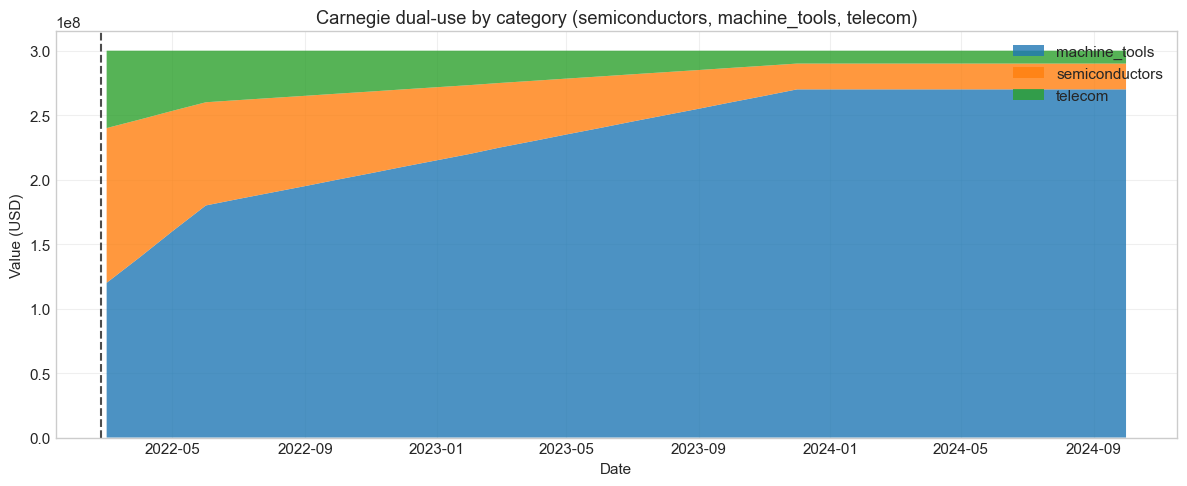

In [5]:
# ============================================================
# Carnegie by category (stacked area)
# ============================================================

carnegie["date"] = pd.to_datetime(carnegie["date"] + "-01")
pivot = carnegie.pivot_table(index="date", columns="category", values="value_usd", aggfunc="sum")
pivot = pivot.fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(pivot.index, *[pivot[c] for c in pivot.columns], labels=pivot.columns, alpha=0.8)
ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Value (USD)")
ax.set_title("Carnegie dual-use by category (semiconductors, machine_tools, telecom)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "nb5_carnegie_by_category.png", dpi=150, bbox_inches="tight")
plt.show()